<a href="https://colab.research.google.com/github/Lakshman3556/Deep_Learning/blob/main/DL_week8.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Implement Auto Encoder model on MINIST datase

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Epoch 1/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 0.3384 - val_loss: 0.2713
Epoch 2/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.2677 - val_loss: 0.2653
Epoch 3/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2648 - val_loss: 0.2639
Epoch 4/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2639 - val_loss: 0.2634
Epoch 5/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2635 - val_loss: 0.2631
Epoch 6/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2633 - val_loss: 0.2630
Epoch 7/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2632 - val_loss: 0.2629
Epoch 8/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2631 - val_loss: 0.2622
Epoch 9/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2600 - val_loss: 0.2574
Epoch 10/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2561 - val_loss: 0.2543
Epoch 11/50
235/235 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 0.2528 - val_loss: 0.2506


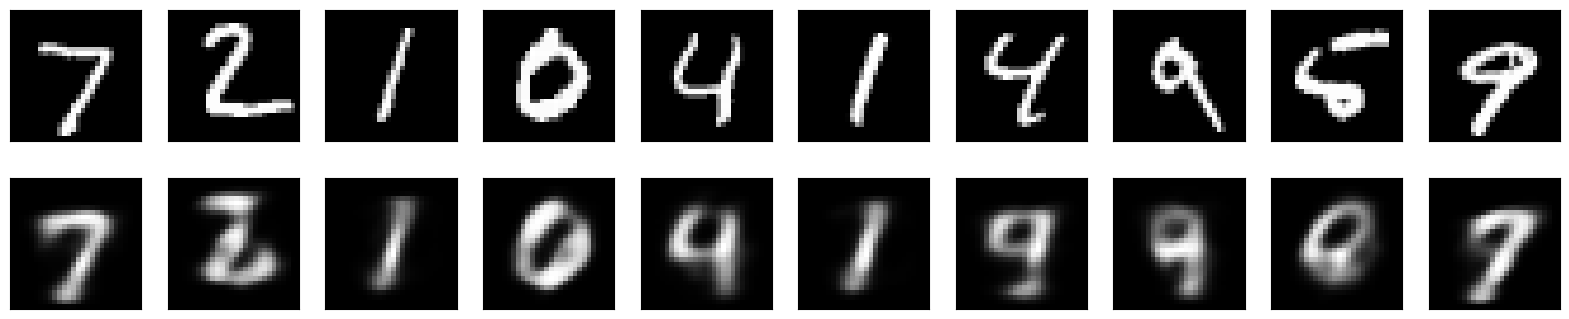

In [ ]:
import numpy as np
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt
from keras.callbacks import TensorBoard
# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.
x_train = x_train.reshape((len(x_train), np.prod(x_train.shape[1:]))) #Original shape: 60000 × 28 × 28 After reshape:60000 × 78
x_test = x_test.reshape((len(x_test), np.prod(x_test.shape[1:]))) #reshape is required for Dense layer expects 1D input vector

# 2. Define the Encoder and Decoder
input_dim = 784  # 28x28 images
encoding_dim = 32  # 32 features - Compressed representation

# Encoder
input_layer = Input(shape=(input_dim,))
encoded = Dense(encoding_dim, activation='sigmoid')(input_layer)

# Decoder
decoded = Dense(input_dim, activation='sigmoid')(encoded)

# 3. Create the Autoencoder Model
autoencoder = Model(input_layer, decoded)

# 4. Compile the Model
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# 5. Train the Model
autoencoder.fit(x_train, x_train, epochs=50, batch_size=256, shuffle=True, validation_data=(x_test, x_test))
#Because autoencoder tries to learn: Input = Output


# 6. Test the Model
decoded_imgs = autoencoder.predict(x_test) #Input:test images Output:reconstructed images

# 7. Visualize Results
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Display original image
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)

    # Display reconstructed image
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28))
    plt.gray()
    ax.get_xaxis().set_visible(False)
    ax.get_yaxis().set_visible(False)
plt.show()


Training Autoencoder with encoding_dim = 8
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded shape: (10000, 8)
Sample encoded vector: [0.8813677  2.124921   0.8267693  2.3696015  0.         0.48473305
 0.34531468 0.7298531 ]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


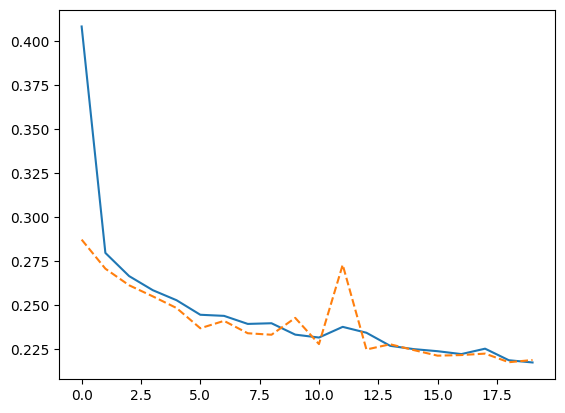

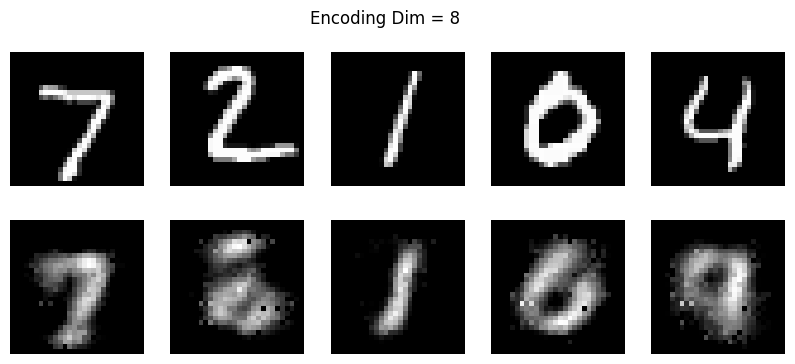


Training Autoencoder with encoding_dim = 16
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded shape: (10000, 16)
Sample encoded vector: [1.3559004  0.         1.6269588  1.0621945  1.5787069  0.
 0.         0.64982206 1.1198462  1.518458  ]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


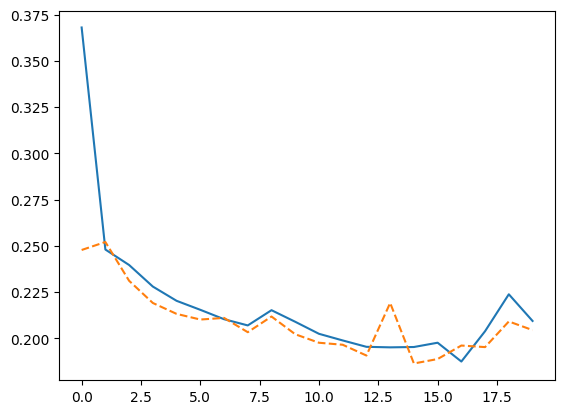

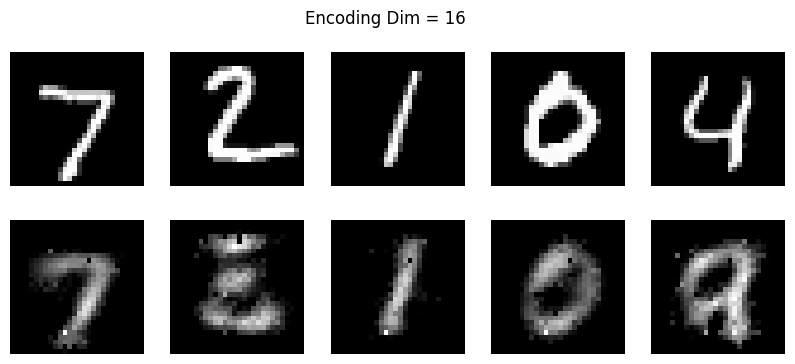


Training Autoencoder with encoding_dim = 32
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded shape: (10000, 32)
Sample encoded vector: [0.         0.         0.92950517 0.         0.19963203 0.11545432
 3.0337148  0.47241443 1.3917905  0.96721834]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


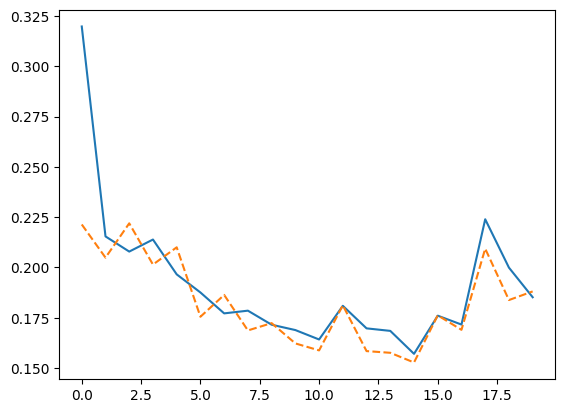

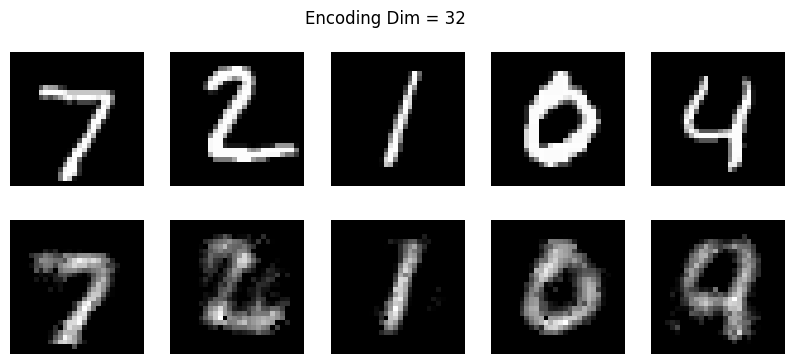


Training Autoencoder with encoding_dim = 64
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Encoded shape: (10000, 64)
Sample encoded vector: [0.        0.4418301 0.        0.        0.        0.        0.
 0.5947373 0.        0.       ]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


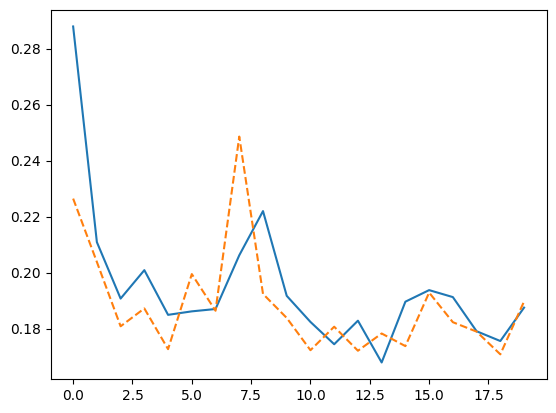

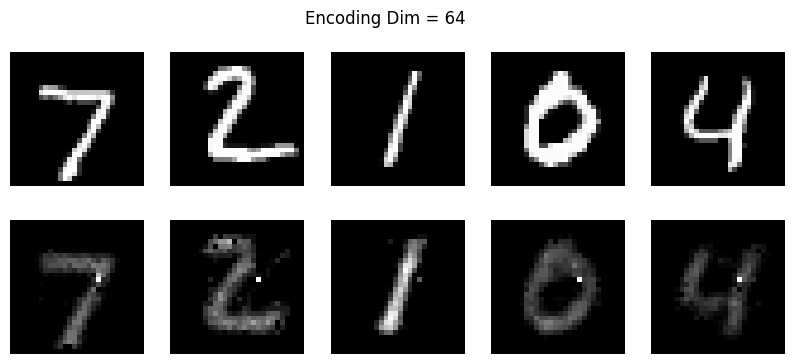


Training Autoencoder with encoding_dim = 128
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Encoded shape: (10000, 128)
Sample encoded vector: [0.         1.5328778  0.         0.         1.2536018  0.
 0.11769041 0.27029306 0.         0.        ]
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


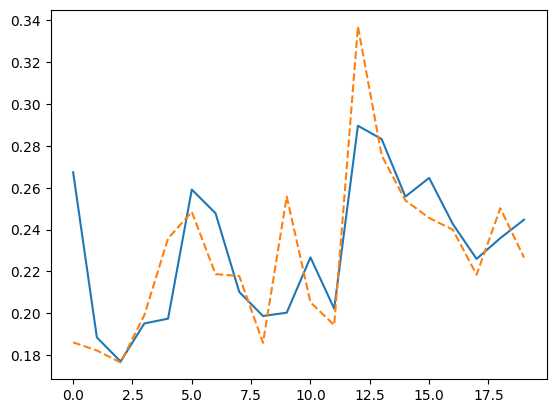

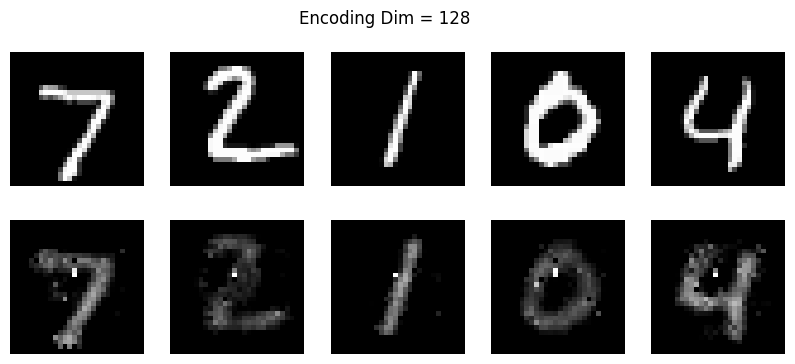


Final Validation Loss for each Encoding Dimension:
Encoding Dim: 8 --> Val Loss: 0.2185956984758377
Encoding Dim: 16 --> Val Loss: 0.20439688861370087
Encoding Dim: 32 --> Val Loss: 0.18807251751422882
Encoding Dim: 64 --> Val Loss: 0.18967178463935852
Encoding Dim: 128 --> Val Loss: 0.22657553851604462


/tmp/ipykernel_3537/1628556247.py:95: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


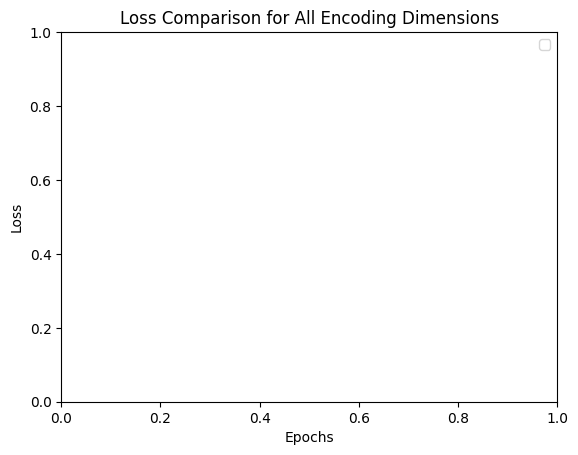

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.models import Model
from tensorflow.keras.datasets import mnist

# 1. Load and Prepare Data
(x_train, _), (x_test, _) = mnist.load_data()

x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

x_train = x_train.reshape((len(x_train), 784))
x_test = x_test.reshape((len(x_test), 784))

# 2. Try Different Encoding Dimensions
encoding_dims = [8, 16, 32, 64, 128]
results = {}

for encoding_dim in encoding_dims:
    print(f"\nTraining Autoencoder with encoding_dim = {encoding_dim}")

    # Encoder
    input_layer = Input(shape=(784,))
    encoded = Dense(encoding_dim, activation='relu')(input_layer)

    # Decoder
    decoded = Dense(784, activation='relu')(encoded)

    # Autoencoder Model
    autoencoder = Model(input_layer, decoded)
    autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

    # Train
    history = autoencoder.fit(
        x_train, x_train,
        epochs=20,
        batch_size=256,
        shuffle=True,
        validation_data=(x_test, x_test),
        verbose=0
    )

    # Save final validation loss
    final_loss = history.history['val_loss'][-1]
    results[encoding_dim] = final_loss

    # Plot Loss Curve
    plt.plot(history.history['loss'], label=f'Train {encoding_dim}')
    plt.plot(history.history['val_loss'], linestyle='--', label=f'Val {encoding_dim}')

    # ----- Encoder Model -----
    encoder = Model(input_layer, encoded)
    encoded_imgs = encoder.predict(x_test)

    print("Encoded shape:", encoded_imgs.shape)
    print("Sample encoded vector:", encoded_imgs[0][:10])

    # ----- Decoder Model -----
    encoded_input = Input(shape=(encoding_dim,))
    decoder_layer = autoencoder.layers[-1]
    decoder = Model(encoded_input, decoder_layer(encoded_input))

    decoded_imgs = decoder.predict(encoded_imgs)

    # ----- Visualization -----
    n = 5
    plt.figure(figsize=(10, 4))
    for i in range(n):
        # Original
        ax = plt.subplot(2, n, i + 1)
        plt.imshow(x_test[i].reshape(28, 28))
        plt.gray()
        ax.axis('off')

        # Reconstructed
        ax = plt.subplot(2, n, i + 1 + n)
        plt.imshow(decoded_imgs[i].reshape(28, 28))
        plt.gray()
        ax.axis('off')

    plt.suptitle(f"Encoding Dim = {encoding_dim}")
    plt.show()

# Final Loss Comparison
print("\nFinal Validation Loss for each Encoding Dimension:")
for dim, loss in results.items():
    print(f"Encoding Dim: {dim} --> Val Loss: {loss}")

# Plot Combined Loss Graph
plt.title("Loss Comparison for All Encoding Dimensions")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()